# Employee Sales Analysis

This notebook analyzes employee sales performance for the Italian Restaurant Analytics project during the period from January to March 2026.

The objective is to evaluate individual employee performance, identify the highest and lowest contributors, compare sales volume with revenue results, and detect meaningful performance patterns during the analyzed three-month period.

To protect employee privacy, real employee names have been anonymized and replaced with generic labels such as `Employee 1`, `Employee 2`, and so on.

## Analysis Scope

- Employee sales summary
- Top employees by sales
- Top employees by quantity
- Quantity vs sales relationship
- Employee performance concentration
- Lowest-performing employees
- Key business insights

In [1]:
# Import the libraries required for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
# Load the cleaned employee sales dataset and display the first five rows

df = pd.read_excel("../data/cleaned/employees_cleaned.xlsx")
df.head()

,Employee,Quantity,Quantity (%),Sales,Sales (%)
0,Employee 1,15786.200000,19.551131,61641.63,19.495142
1,Employee 2,14256.900000,17.657100,54125.31,17.117986
2,Employee 3,12638.866667,15.653174,45762.89,14.473239
3,Employee 4,11382.500000,14.097170,42810.66,13.539549
4,Employee 5,10697.500000,13.248801,40654.99,12.857784


In [3]:
# Inspect the employee sales dataset structure, size, and data types

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (17, 5)

Column names:
['Employee', 'Quantity', 'Quantity (%)', 'Sales', 'Sales (%)']

Data types:
Employee         object
Quantity        float64
Quantity (%)    float64
Sales           float64
Sales (%)       float64
dtype: object


## Employee Sales Summary

This section provides a general overview of employee sales performance during the January–March 2026 period, including total quantity sold, total sales, average sales per employee, and the number of employees analyzed.

In [4]:
# Calculate key summary metrics for employee sales performance

total_quantity = df["Quantity"].sum()
total_sales = df["Sales"].sum()
average_sales_per_employee = df["Sales"].mean()
employee_count = df["Employee"].nunique()

print(f"Total quantity sold: {total_quantity:,.2f}")
print(f"Total sales: ${total_sales:,.2f}")
print(f"Average sales per employee: ${average_sales_per_employee:,.2f}")
print(f"Employees analyzed: {employee_count}")

Total quantity sold: 80,726.16
Total sales: $316,173.70
Average sales per employee: $18,598.45
Employees analyzed: 17


## Top Employees by Sales

This section identifies the employees who generated the highest total sales during the January–March 2026 period, helping highlight the strongest contributors to overall revenue.

In [5]:
# Rank employees from highest to lowest total sales

employee_sales = (
    df[["Employee", "Sales", "Sales (%)"]]
    .sort_values("Sales", ascending=False)
    .reset_index(drop=True)
)

employee_sales.head(10).style.format({
    "Sales": "${:,.2f}",
    "Sales (%)": "{:.2f}%"
})

,Employee,Sales,Sales (%)
0,Employee 1,"$61,641.63",19.50%
1,Employee 2,"$54,125.31",17.12%
2,Employee 3,"$45,762.89",14.47%
3,Employee 4,"$42,810.66",13.54%
4,Employee 5,"$40,654.99",12.86%
5,Employee 6,"$24,884.01",7.87%
6,Employee 7,"$20,890.97",6.61%
7,Employee 8,"$8,458.35",2.68%
8,Employee 9,"$5,343.32",1.69%
9,Employee 10,"$4,883.78",1.54%


### Top Employees by Sales Visualization

The following horizontal bar chart shows the seven employees with the highest total sales during the January–March 2026 period.

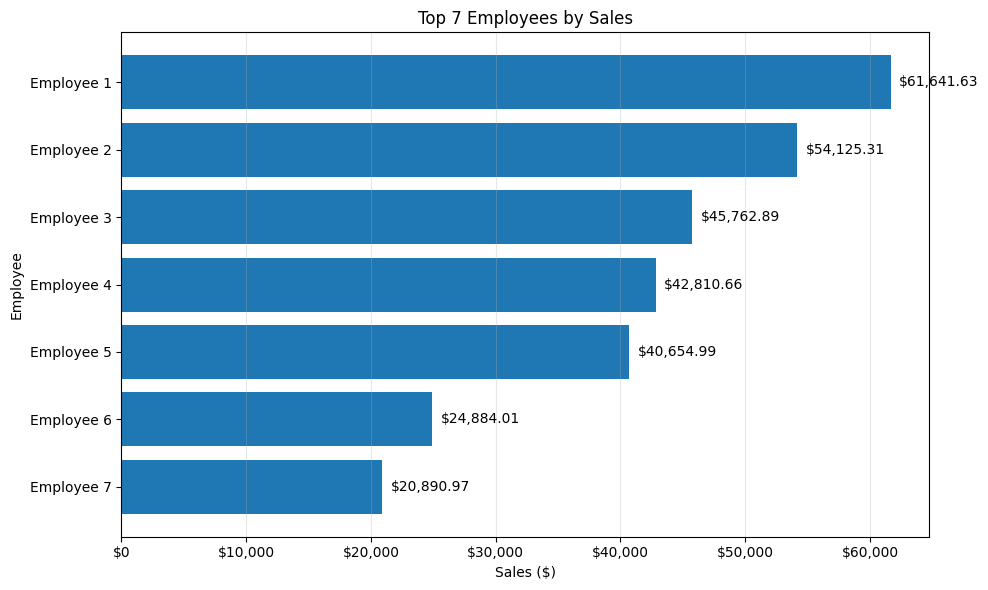

In [6]:
# Create a horizontal bar chart for the seven employees with the highest sales

top_employee_sales = employee_sales.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_employee_sales["Employee"],
    top_employee_sales["Sales"]
)

plt.title("Top 7 Employees by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Employee")

# Display the highest-selling employee at the top
plt.gca().invert_yaxis()

# Format the horizontal axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add sales labels at the end of each bar
for bar, value in zip(
    bars,
    top_employee_sales["Sales"]
):
    plt.text(
        value + 700,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

`Employee 1` was the strongest sales contributor during the January–March 2026 period, generating $61,641.63 in total sales and accounting for approximately 19.50% of overall employee sales.

`Employee 2` followed with $54,125.31, while `Employee 3`, `Employee 4`, and `Employee 5` also represented substantial contributors.

The results show that sales performance is concentrated among a relatively small group of employees, with a noticeable decline after the seventh-ranked employee.

## Top Employees by Quantity

This section identifies the employees associated with the highest total quantity sold during the January–March 2026 period, helping compare sales volume with revenue performance.

In [7]:
# Rank employees from highest to lowest total quantity sold

employee_quantity = (
    df[["Employee", "Quantity", "Quantity (%)"]]
    .sort_values("Quantity", ascending=False)
    .reset_index(drop=True)
)

employee_quantity.head(10).style.format({
    "Quantity": "{:,.2f}",
    "Quantity (%)": "{:.2f}%"
})

,Employee,Quantity,Quantity (%)
0,Employee 1,"15,786.20",19.55%
1,Employee 2,"14,256.90",17.66%
2,Employee 3,"12,638.87",15.65%
3,Employee 4,"11,382.50",14.10%
4,Employee 5,"10,697.50",13.25%
5,Employee 7,"5,788.33",7.17%
6,Employee 6,"3,617.61",4.48%
7,Employee 8,"2,264.91",2.81%
8,Employee 9,"1,394.33",1.73%
9,Employee 10,"1,305.00",1.62%


### Top Employees by Quantity Visualization

The following horizontal bar chart shows the seven employees with the highest total quantity sold during the January–March 2026 period.

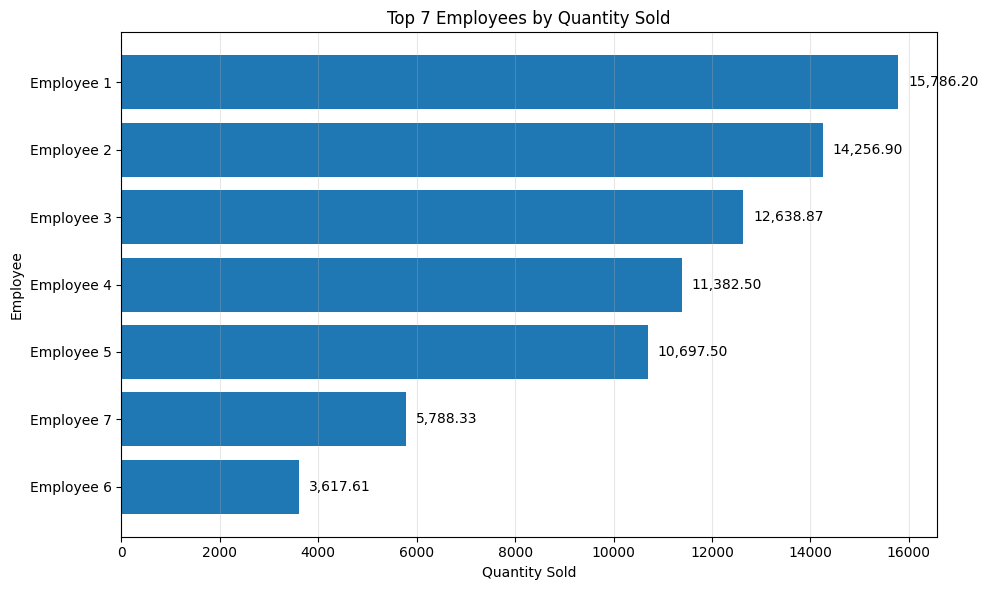

In [8]:
# Create a horizontal bar chart for the seven employees with the highest quantity sold

top_employee_quantity = employee_quantity.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_employee_quantity["Employee"],
    top_employee_quantity["Quantity"]
)

plt.title("Top 7 Employees by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Employee")

# Display the highest quantity at the top
plt.gca().invert_yaxis()

# Add quantity labels at the end of each bar
for bar, value in zip(
    bars,
    top_employee_quantity["Quantity"]
):
    plt.text(
        value + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

`Employee 1` recorded the highest quantity sold during the January–March 2026 period, followed by `Employee 2`, `Employee 3`, `Employee 4`, and `Employee 5`.

The quantity ranking closely mirrors the sales ranking, indicating that higher sales performance is generally associated with higher sales volume.

However, `Employee 7` sold a greater quantity than `Employee 6`, while `Employee 6` generated higher total sales. This suggests differences in the average monetary value associated with the items sold by each employee.

### Quantity vs Sales Visualization

The following scatter plot shows the relationship between quantity sold and total sales by employee during the January–March 2026 period.

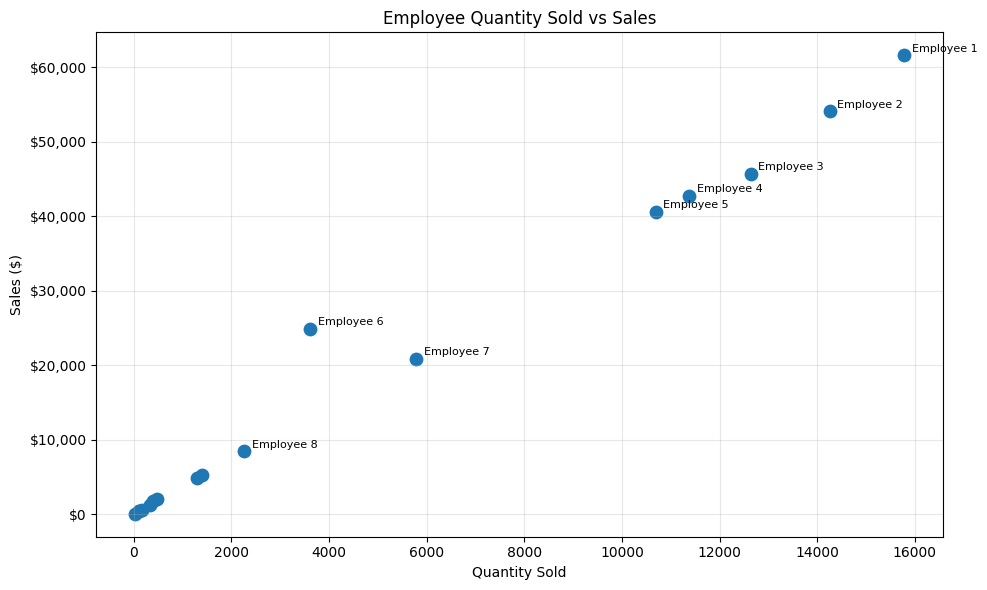

In [9]:
# Create a scatter plot to compare quantity sold with total sales by employee

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["Sales"],
    s=80
)

# Add labels only to the most relevant employees

for _, row in df.iterrows():
    if row["Sales"] >= 8000:
        plt.text(
            row["Quantity"] + 150,
            row["Sales"] + 500,
            row["Employee"],
            fontsize=8
        )

plt.title("Employee Quantity Sold vs Sales")
plt.xlabel("Quantity Sold")
plt.ylabel("Sales ($)")

# Format the vertical axis as currency
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The scatter plot shows a strong positive relationship between quantity sold and total sales during the January–March 2026 period. In general, employees with higher quantities sold also generated higher total sales.

Employees 1 to 5 clearly stand out as the strongest performers, forming the upper-right cluster of the chart. This indicates that they contributed the most both in sales volume and revenue generation.

A notable difference appears between Employee 6 and Employee 7: although Employee 7 sold a higher quantity, Employee 6 generated higher total sales, which may suggest a higher average sales value per unit.

Most of the remaining employees are concentrated in the lower-left area of the chart, reflecting comparatively lower contributions in both quantity sold and total sales.

## Employee Performance Concentration

This section measures how much of the total employee sales performance is concentrated among the top contributors, considering both total sales and total quantity sold.

In [10]:
# Calculate the concentration of sales and quantity among the top five employees

top_five_sales = employee_sales.head(5)["Sales"].sum()
top_five_quantity = employee_quantity.head(5)["Quantity"].sum()

sales_concentration = (top_five_sales / total_sales) * 100
quantity_concentration = (top_five_quantity / total_quantity) * 100

print(f"Top 5 employees sales: ${top_five_sales:,.2f}")
print(f"Share of total sales: {sales_concentration:.2f}%")

print(f"\nTop 5 employees quantity sold: {top_five_quantity:,.2f}")
print(f"Share of total quantity: {quantity_concentration:.2f}%")

Top 5 employees sales: $244,995.48
Share of total sales: 77.49%

Top 5 employees quantity sold: 64,761.97
Share of total quantity: 80.22%


### Employee Performance Concentration Visualization

The following chart compares the share of total sales and total quantity generated by the five leading employees.

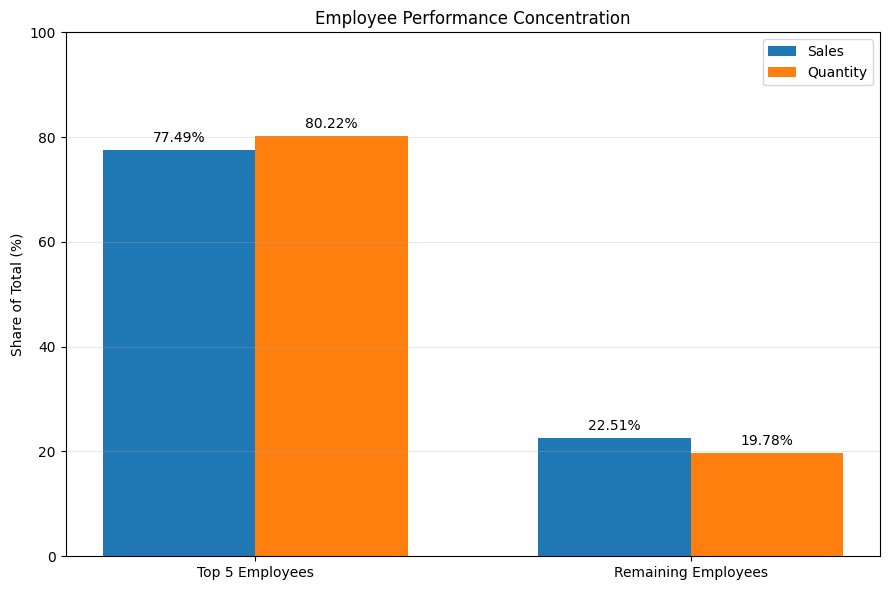

In [11]:
# Compare the performance concentration of the top five employees with the remaining employees

remaining_sales_concentration = 100 - sales_concentration
remaining_quantity_concentration = 100 - quantity_concentration

concentration_comparison = pd.DataFrame({
    "Metric": ["Sales", "Sales", "Quantity", "Quantity"],
    "Group": [
        "Top 5 Employees",
        "Remaining Employees",
        "Top 5 Employees",
        "Remaining Employees"
    ],
    "Share (%)": [
        sales_concentration,
        remaining_sales_concentration,
        quantity_concentration,
        remaining_quantity_concentration
    ]
})

sales_values = [
    sales_concentration,
    remaining_sales_concentration
]

quantity_values = [
    quantity_concentration,
    remaining_quantity_concentration
]

x = [0, 1]
width = 0.35

plt.figure(figsize=(9, 6))

bars1 = plt.bar(
    [i - width / 2 for i in x],
    sales_values,
    width,
    label="Sales"
)

bars2 = plt.bar(
    [i + width / 2 for i in x],
    quantity_values,
    width,
    label="Quantity"
)

plt.xticks(
    x,
    ["Top 5 Employees", "Remaining Employees"]
)

plt.title("Employee Performance Concentration")
plt.ylabel("Share of Total (%)")
plt.ylim(0, 100)

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1.5,
            f"{value:.2f}%",
            ha="center"
        )

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The five leading employees generated 77.49% of total sales and 80.22% of total quantity sold during the January–March 2026 period.

This indicates a high level of performance concentration, with a relatively small group of employees accounting for the majority of both revenue and sales volume.

The remaining employees collectively represented only 22.51% of total sales and 19.78% of total quantity sold, reinforcing the importance of the top-performing group to overall employee sales performance.

## Lowest-Performing Employees

This section identifies the employees with the lowest total sales during the January–March 2026 period, helping highlight the lower end of the performance distribution.

These results should be interpreted carefully, as lower sales may be influenced by factors not included in the dataset, such as working hours, shift allocation, role differences, or time employed during the analyzed period.

In [12]:
# Rank employees from lowest to highest total sales

lowest_employee_sales = (
    df[["Employee", "Sales", "Sales (%)", "Quantity", "Quantity (%)"]]
    .sort_values("Sales", ascending=True)
    .reset_index(drop=True)
)

lowest_employee_sales.head(5).style.format({
    "Sales": "${:,.2f}",
    "Sales (%)": "{:.2f}%",
    "Quantity": "{:,.2f}",
    "Quantity (%)": "{:.2f}%"
})

,Employee,Sales,Sales (%),Quantity,Quantity (%)
0,Employee 17,$73.21,0.02%,23.00,0.03%
1,Employee 16,$397.66,0.13%,107.00,0.13%
2,Employee 15,$453.18,0.14%,116.40,0.14%
3,Employee 14,$576.60,0.18%,162.60,0.20%
4,Employee 13,"$1,282.71",0.41%,331.00,0.41%


### Key Insight

The five lowest-performing employees accounted for only a very small share of total sales during the January–March 2026 period.

`Employee 17` recorded the lowest sales contribution at $73.21, representing approximately 0.02% of total employee sales. `Employee 16`, `Employee 15`, and `Employee 14` also contributed less than 0.20% individually.

The similarity between their low sales shares and low quantity shares indicates that their lower revenue contribution was primarily associated with limited sales volume.

However, these results should not be interpreted as direct measures of individual productivity, since the dataset does not include information such as working hours, shift allocation, employment duration, or job responsibilities.

## Employee Sales Analysis Summary

The employee sales analysis covers the January–March 2026 period and includes 17 anonymized employees.

During the analyzed period, employees generated $316,173.70 in total sales and 80,726.16 in total quantity sold, with average sales of $18,598.45 per employee.

`Employee 1` was the strongest contributor, generating $61,641.63 in total sales and accounting for approximately 19.50% of overall employee sales. `Employee 2`, `Employee 3`, `Employee 4`, and `Employee 5` also represented major contributors.

The rankings by sales and quantity were broadly similar, indicating a strong relationship between sales volume and revenue generation. However, some differences were observed, such as `Employee 6` generating higher sales than `Employee 7` despite selling a lower quantity.

The five leading employees generated 77.49% of total sales and 80.22% of total quantity sold, showing a high level of performance concentration among a relatively small group of employees.

At the lower end of the distribution, several employees accounted for only a very small share of total sales and quantity. These results should be interpreted cautiously, since the dataset does not include information such as working hours, shift allocation, employment duration, or job responsibilities.

Overall, employee sales performance during the analyzed period was strongly concentrated among the top contributors, while quantity sold and total sales showed a clear positive relationship.

---

## Author

**Guido Acosta**

Data Analyst Portfolio Project

GitHub Portfolio – 2026